✅ Packages ready
Output folder: c:\Users\bsevak\Documents\project_data\gwas_output\classwise_analysis

STEP 1 — Loading original full dataset
Total samples    : 3700
Cases (gall=Yes) : 172
Controls (gall=No): 3528
SNP features     : will load from .raw files
Metabolites      : 302
Clinical         : 4
PCs              : 4

STEP 2 — Loading SNPs
SNPs loaded: 479
  CDHR3_region.raw: 36 SNPs
  CLDN7_region.raw: 41 SNPs
  CPZ_region.raw: 51 SNPs
  ERICH1_region.raw: 42 SNPs
  EXOC4_region.raw: 39 SNPs
  GALNTL6_region.raw: 44 SNPs
  GPC6_region.raw: 33 SNPs
  GPRIN3_region.raw: 13 SNPs
  HLA-G_region.raw: 19 SNPs
  HMGB1P5_region.raw: 16 SNPs
  LINC01122_region.raw: 10 SNPs
  LRP8_region.raw: 13 SNPs
  LUZP2_region.raw: 16 SNPs
  MATN2_region.raw: 11 SNPs
  OSBPL10_region.raw: 18 SNPs
  PALM2AKAP2_region.raw: 8 SNPs
  PTPRN2_region.raw: 14 SNPs
  RNFT2_region.raw: 19 SNPs
  RPL31P35_region.raw: 10 SNPs
  TJP1_region.raw: 9 SNPs
  UGGT1_region.raw: 17 SNPs
Genotype shape: (3700, 480)

STEP 

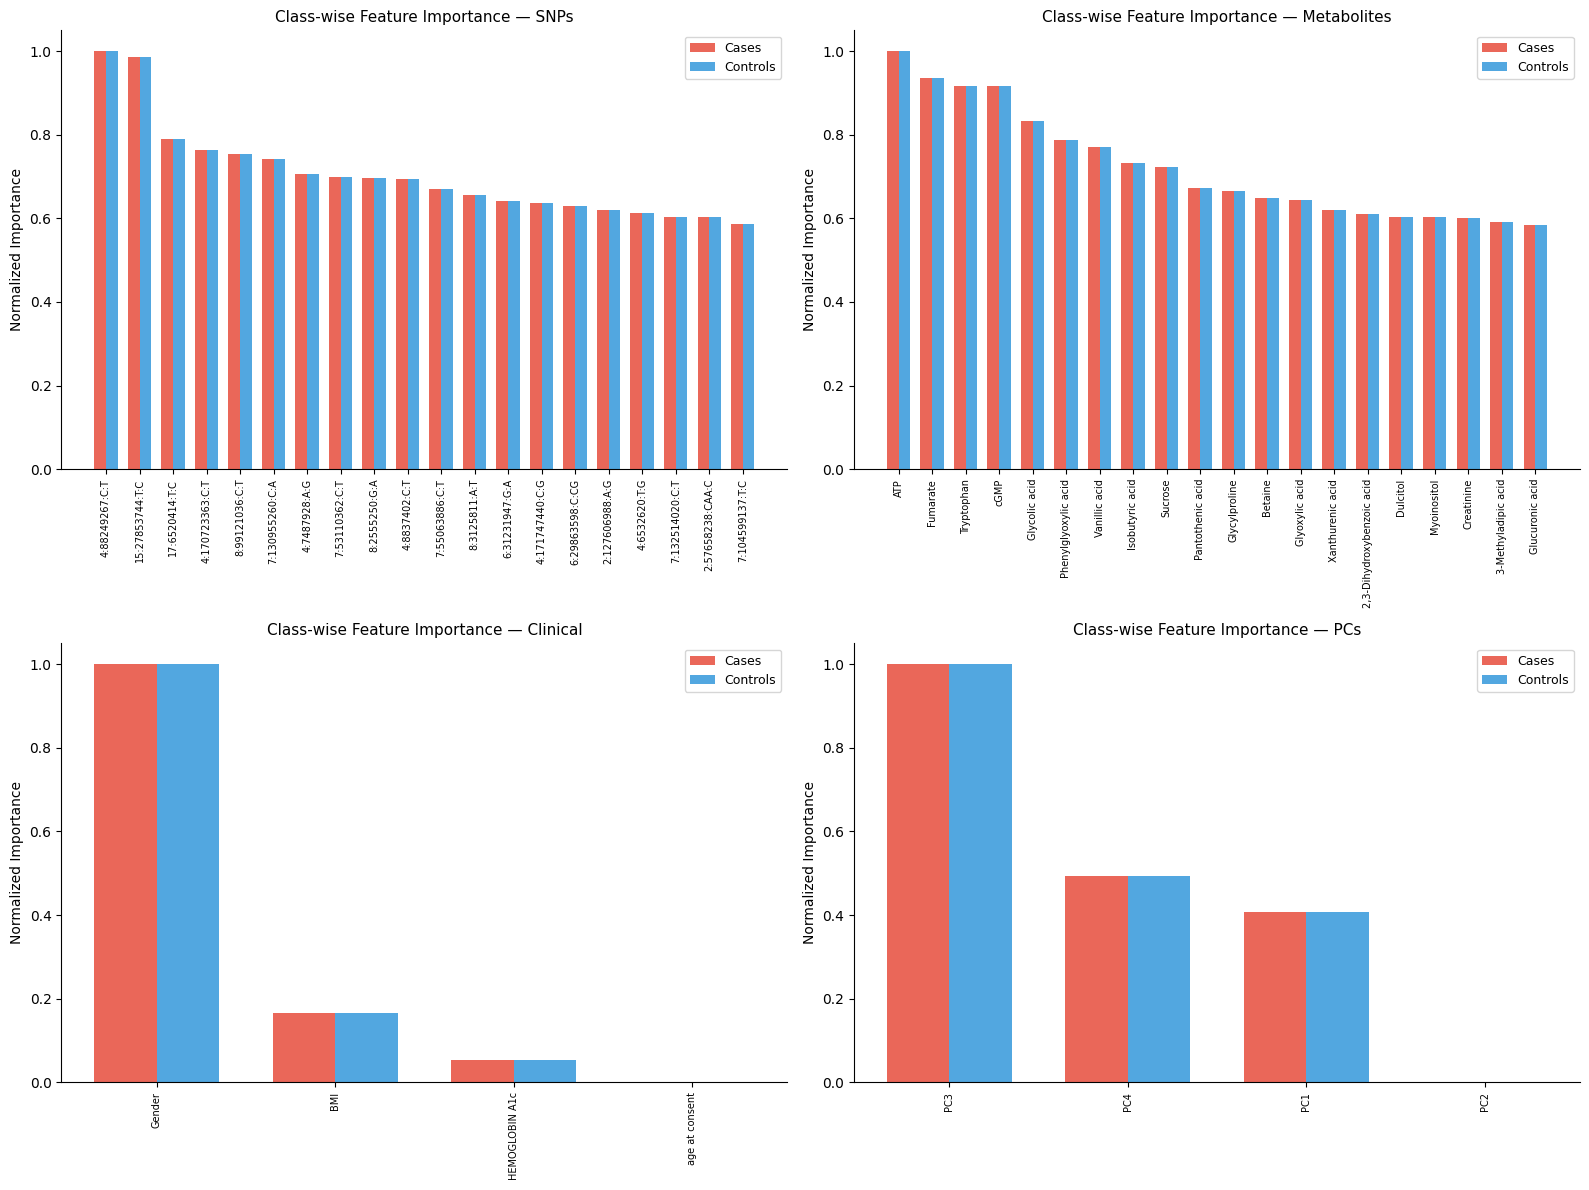

✅ Saved: classwise_feature_selection.png

STEP 6 — Building Final Feature Matrix
Total selected features (union of all class-wise): 108
  From SNPs       : 50
  From Metabolites: 50
  From Clinical   : 4
  From PCs        : 4

STEP 7 — Standardization vs Normalization Comparison

Training with: No Scaling ...
  ✅ CV AUC : 0.5878 +/- 0.0347
  ✅ Test AUC: 0.5976 | Accuracy: 0.9457
              precision    recall  f1-score   support

     Control       0.96      0.99      0.97       703
        Case       0.25      0.09      0.13        34

    accuracy                           0.95       737
   macro avg       0.60      0.54      0.55       737
weighted avg       0.92      0.95      0.93       737


Training with: Standardized ...
  ✅ CV AUC : 0.5879 +/- 0.0345
  ✅ Test AUC: 0.5972 | Accuracy: 0.9457
              precision    recall  f1-score   support

     Control       0.96      0.99      0.97       703
        Case       0.25      0.09      0.13        34

    accuracy           

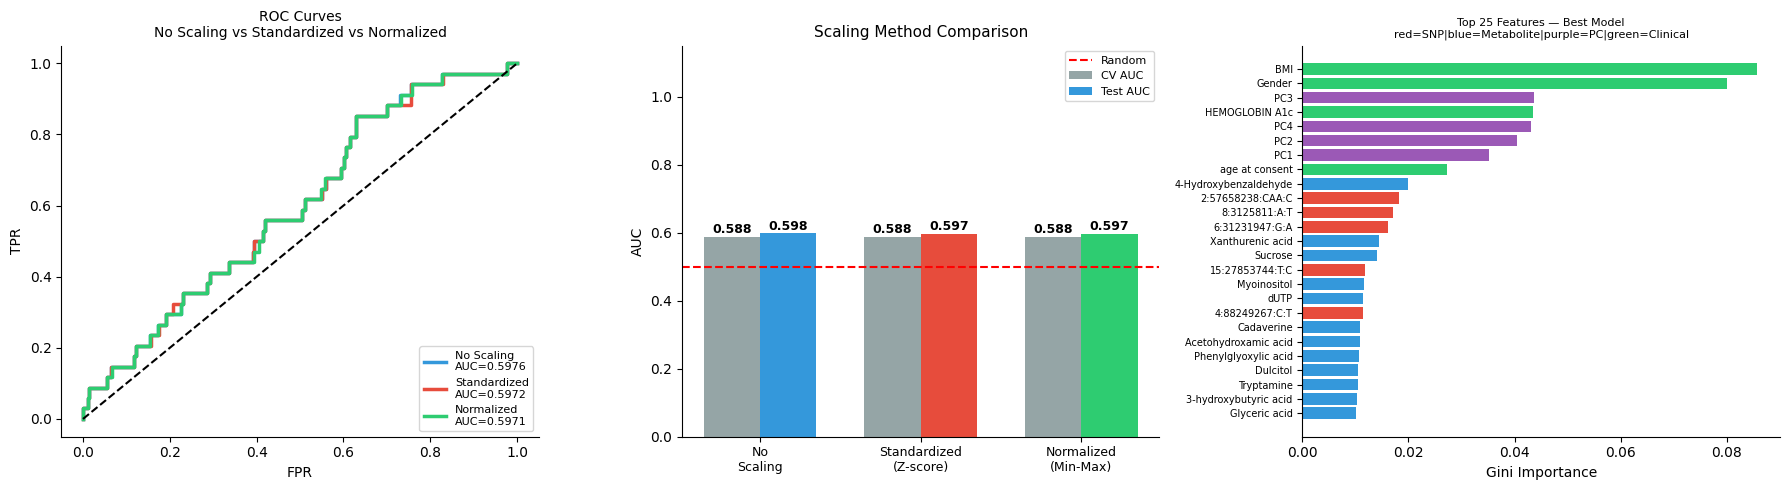

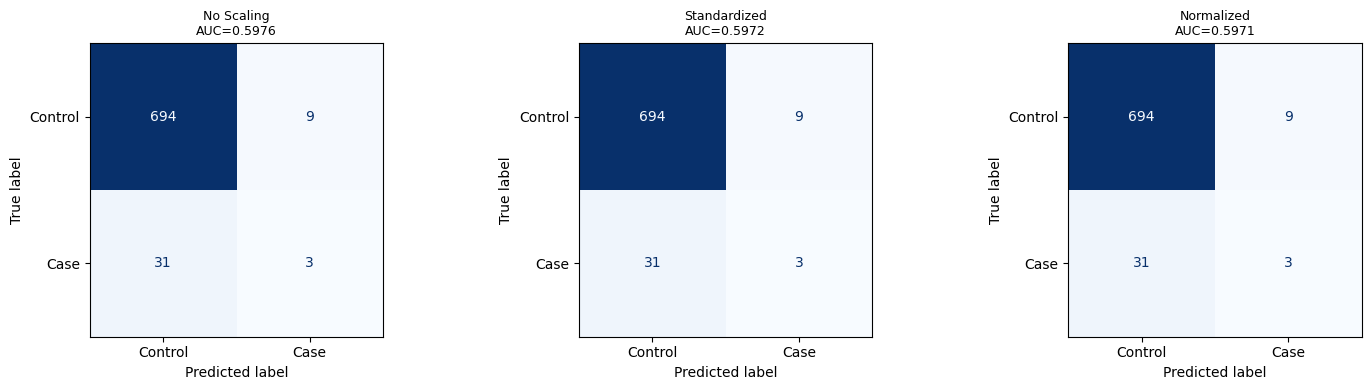

ValueError: All arrays must be of the same length

In [1]:
import os, warnings, sys, subprocess
from pathlib import Path

for pkg in ['pandas','numpy','scipy','scikit-learn','matplotlib','seaborn','openpyxl','imbalanced-learn']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'-q'])
print('✅ Packages ready')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve)
from imblearn.ensemble import BalancedRandomForestClassifier
warnings.filterwarnings('ignore')
%matplotlib inline

BASE       = Path(os.getcwd())
OUT        = BASE / 'gwas_output' / 'classwise_analysis'
OUT.mkdir(parents=True, exist_ok=True)
SNP_CSV    = BASE / 'summary_results sorted by p (1).csv'
PHENO_XLSX = BASE / 'final_merged_cleaned.xlsx'
CASES_TXT  = BASE / 'ID_gsd_172cases.txt'
CTRLS_TXT  = BASE / 'ID_gsd_1032controls.txt'

print(f'Output folder: {OUT}')

# ── IID2 date fix ─────────────────────────────────────────────────────────────
def fix_iid2(val):
    if pd.isna(val): return val
    val = str(val).strip()
    if val.startswith('2025-') and ('00:00:00' in val or len(val)==10):
        try:
            parts = val.replace(' 00:00:00','').split('-')
            return f'{parts[2]}-{parts[1]}'
        except: return val
    return val

# ── STEP 1: Load ALL original data ───────────────────────────────────────────
print('\n' + '='*60)
print('STEP 1 — Loading original full dataset')
print('='*60)

pheno = pd.read_excel(PHENO_XLSX, dtype=str)
pheno = pheno.apply(lambda col: col.map(
    lambda x: x.strip() if isinstance(x, str) else x))
pheno.columns = pheno.columns.str.replace('\n',' ').str.strip()
pheno['IID2'] = pheno['IID2'].apply(fix_iid2)
pheno['gall']  = pheno['gall'].str.lower()
pheno          = pheno[pheno['gall'].isin({'yes','no'})].copy()
pheno['label'] = (pheno['gall']=='yes').astype(int)
pheno['IID2']  = pheno['IID2'].astype(str)

# Feature columns
non_feat  = ['External_ID_x','External_ID','sampid','FID','IID','FID2',
             'IID2','SAMPLEID','gall','dys','Unnamed: 16','label']
pc_cols   = ['PC1','PC2','PC3','PC4']
clin_cols = ['age at consent','Gender','BMI','HEMOGLOBIN A1c']
meta_cols = [c for c in pheno.columns
             if c not in non_feat+pc_cols+clin_cols
             and not c.startswith('PC')
             and not c.startswith('Unnamed')]

# Encode Gender
if 'Gender' in pheno.columns:
    pheno['Gender'] = LabelEncoder().fit_transform(pheno['Gender'].fillna('Unknown'))
for col in clin_cols + pc_cols + meta_cols:
    if col in pheno.columns:
        pheno[col] = pd.to_numeric(pheno[col], errors='coerce')

available_clin = [c for c in clin_cols if c in pheno.columns]
available_meta = [c for c in meta_cols if c in pheno.columns]
available_pcs  = [c for c in pc_cols   if c in pheno.columns]

print(f'Total samples    : {len(pheno)}')
print(f'Cases (gall=Yes) : {pheno["label"].sum()}')
print(f'Controls (gall=No): {(pheno["label"]==0).sum()}')
print(f'SNP features     : will load from .raw files')
print(f'Metabolites      : {len(available_meta)}')
print(f'Clinical         : {len(available_clin)}')
print(f'PCs              : {len(available_pcs)}')

# ── STEP 2: Load SNPs ─────────────────────────────────────────────────────────
print('\n' + '='*60)
print('STEP 2 — Loading SNPs')
print('='*60)

snp_raw = pd.read_csv(SNP_CSV)
snp_raw = snp_raw[snp_raw['MinP'] <= 1e-5]
snp_df  = (snp_raw[['Gene','TopSNP','MinP']]
           .sort_values('MinP')
           .drop_duplicates(subset='TopSNP')
           .reset_index(drop=True))
print(f'SNPs loaded: {len(snp_df)}')

def load_raw(raw_path, snp_list):
    header  = pd.read_csv(raw_path, sep=r'\s+', nrows=0)
    snp_set = set(snp_list)
    col_map = {c: c.rsplit('_',1)[0] for c in header.columns
               if c.rsplit('_',1)[0] in snp_set}
    if not col_map: return pd.DataFrame()
    df = pd.read_csv(raw_path, sep=r'\s+',
                     usecols=['IID']+list(col_map), low_memory=False)
    df.rename(columns=col_map, inplace=True)
    df['IID'] = df['IID'].astype(str)
    print(f'  {raw_path.name}: {len(col_map)} SNPs')
    return df

raw_files = sorted(BASE.glob('*_region.raw'))
gene_map  = {f.stem.replace('_region','').strip('_').upper(): f for f in raw_files}
gene_snps = snp_df.groupby('Gene')['TopSNP'].apply(list).to_dict()

frames = []
for gene, snps in gene_snps.items():
    g    = gene.upper().strip()
    path = gene_map.get(g)
    if path is None:
        matches = [k for k in gene_map if k.startswith(g) or g.startswith(k)]
        path = gene_map[matches[0]] if matches else None
    if path is None: continue
    chunk = load_raw(path, snps)
    if not chunk.empty: frames.append(chunk)

geno = frames[0]
for f in frames[1:]:
    geno = pd.merge(geno, f, on='IID', how='outer')
geno = geno.loc[:, ~geno.columns.duplicated()]
print(f'Genotype shape: {geno.shape}')

# ── STEP 3: Merge ALL samples (not filtered) ──────────────────────────────────
print('\n' + '='*60)
print('STEP 3 — Merging ALL original samples')
print('='*60)

keep = ['IID2','gall','label'] + available_pcs + available_clin + available_meta
keep = [c for c in keep if c in pheno.columns]

merged_all = pd.merge(geno, pheno[keep],
                      left_on='IID', right_on='IID2', how='inner')
merged_all['label'] = merged_all['label'].astype(int)

snp_cols  = [c for c in merged_all.columns if c in set(geno.columns)-{'IID'}]
all_feats = {
    'SNPs'       : snp_cols,
    'Metabolites': [c for c in available_meta  if c in merged_all.columns],
    'Clinical'   : [c for c in available_clin  if c in merged_all.columns],
    'PCs'        : [c for c in available_pcs   if c in merged_all.columns],
}

print(f'Merged ALL samples: {merged_all.shape}')
print(f'Cases   : {merged_all["label"].sum()}')
print(f'Controls: {(merged_all["label"]==0).sum()}')
for name, cols in all_feats.items():
    print(f'{name:15s}: {len(cols)} features')

# ── STEP 4: CLASS-WISE FEATURE SELECTION ─────────────────────────────────────
print('\n' + '='*60)
print('STEP 4 — Class-wise Feature Selection')
print('='*60)
print('Selecting top features SEPARATELY for Cases and Controls')

def classwise_feature_selection(data, feature_cols, label_col='label',
                                 top_n=50, method='mutual_info'):
    """
    Select top features separately for each class.
    Cases  → top features that best characterize cases
    Controls → top features that best characterize controls
    Then union both lists.
    """
    cases    = data[data[label_col]==1][feature_cols]
    controls = data[data[label_col]==0][feature_cols]
    all_data = data[feature_cols]
    y        = data[label_col]

    # Impute missing
    imp = SimpleImputer(strategy='median')
    X_all = imp.fit_transform(all_data)

    # ── Feature importance for CASES (using cases vs rest) ────────────────────
    y_case = (y == 1).astype(int)
    if method == 'mutual_info':
        scores_case = mutual_info_classif(X_all, y_case, random_state=42)
    else:
        scores_case = f_classif(X_all, y_case)[0]
        scores_case = np.nan_to_num(scores_case)

    # ── Feature importance for CONTROLS (using controls vs rest) ──────────────
    y_ctrl = (y == 0).astype(int)
    if method == 'mutual_info':
        scores_ctrl = mutual_info_classif(X_all, y_ctrl, random_state=42)
    else:
        scores_ctrl = f_classif(X_all, y_ctrl)[0]
        scores_ctrl = np.nan_to_num(scores_ctrl)

    # Top N for each class
    top_case_idx = np.argsort(scores_case)[::-1][:top_n]
    top_ctrl_idx = np.argsort(scores_ctrl)[::-1][:top_n]

    top_case_feats = [feature_cols[i] for i in top_case_idx]
    top_ctrl_feats = [feature_cols[i] for i in top_ctrl_idx]

    # Union of both
    selected = list(dict.fromkeys(top_case_feats + top_ctrl_feats))

    return selected, top_case_feats, top_ctrl_feats, scores_case, scores_ctrl

# Run class-wise selection for each feature type
selected_features = {}
TOP_N = 50  # top 50 per class per feature type

for feat_name, feat_cols in all_feats.items():
    if len(feat_cols) == 0:
        continue
    print(f'\n  Selecting top {TOP_N} features per class for: {feat_name}')

    selected, case_top, ctrl_top, sc_case, sc_ctrl = classwise_feature_selection(
        merged_all, feat_cols, top_n=min(TOP_N, len(feat_cols)),
        method='mutual_info'
    )
    selected_features[feat_name] = {
        'all_selected' : selected,
        'case_top'     : case_top,
        'ctrl_top'     : ctrl_top,
        'scores_case'  : sc_case,
        'scores_ctrl'  : sc_ctrl,
        'feature_cols' : feat_cols,
    }

    print(f'    Case-top features    : {len(case_top)}')
    print(f'    Control-top features : {len(ctrl_top)}')
    print(f'    Union (selected)     : {len(selected)}')
    print(f'    Top 5 for Cases   : {case_top[:5]}')
    print(f'    Top 5 for Controls: {ctrl_top[:5]}')

# ── STEP 5: Visualize class-wise feature selection ────────────────────────────
print('\n' + '='*60)
print('STEP 5 — Visualizing Class-wise Feature Selection')
print('='*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax_idx, (feat_name, info) in enumerate(selected_features.items()):
    if ax_idx >= 4: break
    ax = axes[ax_idx]
    feat_cols   = info['feature_cols']
    scores_case = info['scores_case']
    scores_ctrl = info['scores_ctrl']

    top_n_plot = min(20, len(feat_cols))
    # Get union top features for plotting
    union_idx = np.argsort(scores_case + scores_ctrl)[::-1][:top_n_plot]

    x    = np.arange(top_n_plot)
    w    = 0.35
    sc   = scores_case[union_idx]
    sct  = scores_ctrl[union_idx]
    labs = [feat_cols[i] for i in union_idx]

    # Normalize for display
    sc_norm  = sc  / (sc.max()  + 1e-8)
    sct_norm = sct / (sct.max() + 1e-8)

    ax.bar(x - w/2, sc_norm,  w, label='Cases',    color='#e74c3c', alpha=0.85)
    ax.bar(x + w/2, sct_norm, w, label='Controls', color='#3498db', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labs, rotation=90, fontsize=7)
    ax.set_ylabel('Normalized Importance')
    ax.set_title(f'Class-wise Feature Importance — {feat_name}', fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUT/'classwise_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: classwise_feature_selection.png')

# ── STEP 6: Build final feature matrix with selected features ─────────────────
print('\n' + '='*60)
print('STEP 6 — Building Final Feature Matrix')
print('='*60)

# Combine all selected features
final_selected = []
for feat_name, info in selected_features.items():
    final_selected.extend(info['all_selected'])
final_selected = list(dict.fromkeys(final_selected))  # remove duplicates

print(f'Total selected features (union of all class-wise): {len(final_selected)}')
print(f'  From SNPs       : {len(selected_features.get("SNPs",{}).get("all_selected",[]))}')
print(f'  From Metabolites: {len(selected_features.get("Metabolites",{}).get("all_selected",[]))}')
print(f'  From Clinical   : {len(selected_features.get("Clinical",{}).get("all_selected",[]))}')
print(f'  From PCs        : {len(selected_features.get("PCs",{}).get("all_selected",[]))}')

# ── STEP 7: Standardization vs Normalization comparison ───────────────────────
print('\n' + '='*60)
print('STEP 7 — Standardization vs Normalization Comparison')
print('='*60)

# Raw feature matrix
X_raw = merged_all[final_selected].apply(pd.to_numeric, errors='coerce')
y     = merged_all['label'].astype(int).values

# Impute first
imputer = SimpleImputer(strategy='median')
X_imp   = imputer.fit_transform(X_raw)

# Three versions
scalers = {
    'No Scaling'      : X_imp.copy(),
    'Standardized\n(Z-score, mean=0, std=1)'  : StandardScaler().fit_transform(X_imp),
    'Normalized\n(Min-Max, 0-1)'              : MinMaxScaler().fit_transform(X_imp),
}

cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_list = []
trained      = {}

for scale_name, X_scaled in scalers.items():
    print(f'\nTraining with: {scale_name.split(chr(10))[0]} ...')

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.20, random_state=42, stratify=y)

    model = BalancedRandomForestClassifier(
        n_estimators=200, max_depth=6,
        random_state=42, n_jobs=-1,
        sampling_strategy='auto', replacement=True)

    cv_auc = cross_val_score(model, X_tr, y_tr, cv=cv,
                              scoring='roc_auc', n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:,1]

    prec,rec,thr = precision_recall_curve(y_te, y_prob)
    f1s         = 2*prec*rec/(prec+rec+1e-8)
    best_thresh = thr[np.argmax(f1s)]
    y_pred      = (y_prob >= best_thresh).astype(int)

    auc = roc_auc_score(y_te, y_prob)
    acc = accuracy_score(y_te, y_pred)

    print(f'  ✅ CV AUC : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}')
    print(f'  ✅ Test AUC: {auc:.4f} | Accuracy: {acc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Control','Case']))

    trained[scale_name] = (model, auc, y_prob, y_pred, y_te)
    results_list.append({
        'Scaling'     : scale_name.replace('\n',' '),
        'N Features'  : len(final_selected),
        'CV AUC'      : round(cv_auc.mean(), 4),
        'CV AUC std'  : round(cv_auc.std(),  4),
        'Test AUC'    : round(auc, 4),
        'CV-Test Gap' : round(cv_auc.mean()-auc, 4),
        'N Samples'   : len(merged_all),
        'N Cases'     : int(y.sum()),
        'N Controls'  : int((y==0).sum()),
    })

# ── STEP 8: Plots — compare scaling methods ───────────────────────────────────
print('\n' + '='*60)
print('STEP 8 — Plots')
print('='*60)

colors = ['#3498db','#e74c3c','#2ecc71']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curves
for (name,(model,auc,y_prob,_,y_te)),color in zip(trained.items(),colors):
    fpr,tpr,_ = roc_curve(y_te, y_prob)
    short = name.split('\n')[0]
    axes[0].plot(fpr, tpr, lw=2.5, color=color,
                 label=f'{short}\nAUC={auc:.4f}')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves\nNo Scaling vs Standardized vs Normalized', fontsize=10)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].spines[['top','right']].set_visible(False)

# AUC comparison bar
names_s  = ['No\nScaling','Standardized\n(Z-score)','Normalized\n(Min-Max)']
aucs     = [r['Test AUC'] for r in results_list]
cv_aucs  = [r['CV AUC']   for r in results_list]
x = np.arange(3); w = 0.35
axes[1].bar(x-w/2, cv_aucs, w, label='CV AUC',   color='#95a5a6')
axes[1].bar(x+w/2, aucs,    w, label='Test AUC', color=colors)
for i,(cv,te) in enumerate(zip(cv_aucs,aucs)):
    axes[1].text(i-w/2, cv+0.01, f'{cv:.3f}', ha='center',
                 fontsize=9, fontweight='bold')
    axes[1].text(i+w/2, te+0.01, f'{te:.3f}', ha='center',
                 fontsize=9, fontweight='bold')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Random')
axes[1].set_xticks(x); axes[1].set_xticklabels(names_s, fontsize=9)
axes[1].set_ylabel('AUC'); axes[1].set_ylim(0, 1.15)
axes[1].set_title('Scaling Method Comparison', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].spines[['top','right']].set_visible(False)

# Feature importance — best model
best_name  = max(trained, key=lambda x: trained[x][1])
best_model = trained[best_name][0]
imp        = best_model.feature_importances_
top_n      = min(25, len(final_selected))
idx        = np.argsort(imp)[::-1][:top_n]
cb = []
for i in idx:
    f = final_selected[i]
    if f in snp_cols:                   cb.append('#e74c3c')
    elif f in available_meta:           cb.append('#3498db')
    elif f in available_pcs:            cb.append('#9b59b6')
    else:                               cb.append('#2ecc71')
axes[2].barh(range(top_n), imp[idx][::-1], color=cb[::-1])
axes[2].set_yticks(range(top_n))
axes[2].set_yticklabels([final_selected[i] for i in idx][::-1], fontsize=7)
axes[2].set_xlabel('Gini Importance')
axes[2].set_title(f'Top {top_n} Features — Best Model\nred=SNP|blue=Metabolite|purple=PC|green=Clinical',
                  fontsize=8)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUT/'scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i,(name,(model,auc,y_prob,y_pred,y_te)) in enumerate(trained.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_te, y_pred),
        display_labels=['Control','Case']
    ).plot(ax=axes[i], colorbar=False, cmap='Blues')
    short = name.split('\n')[0]
    axes[i].set_title(f'{short}\nAUC={auc:.4f}', fontsize=9)
plt.tight_layout()
plt.savefig(OUT/'scaling_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── STEP 9: Save results ──────────────────────────────────────────────────────
results_df = pd.DataFrame(results_list)
results_df.to_csv(OUT/'classwise_scaling_results.csv', index=False)

# Save selected features per class
for feat_name, info in selected_features.items():
    pd.DataFrame({
        'Feature'       : info['feature_cols'],
        'Case_Score'    : info['scores_case'],
        'Control_Score' : info['scores_ctrl'],
        'In_Case_Top'   : [f in info['case_top'] for f in info['feature_cols']],
        'In_Ctrl_Top'   : [f in info['ctrl_top'] for f in info['feature_cols']],
    }).sort_values('Case_Score', ascending=False).to_csv(
        OUT/f'classwise_scores_{feat_name}.csv', index=False)

print('\n'+'='*60)
print('  ✅ COMPLETE — Class-wise Feature Selection + Scaling')
print(f'  Total features selected: {len(final_selected)}')
print(f'  Total samples          : {len(merged_all)}')
print(f'  Cases                  : {merged_all["label"].sum()}')
print(f'  Controls               : {(merged_all["label"]==0).sum()}')
print('='*60)
display(results_df)